In [70]:
import numpy as np
from numpy.polynomial.hermite import hermgauss
import math
from scipy.special import eval_hermite
from matplotlib import pyplot as plt

In [112]:
hbar_squared_over_2_mu = 41.467 # MeV*fm^2
hbar = 6.582E-22 # MeV s
v_r = 200 # MeV
k_r = 1.487 # fm^(-2)
v_t = -178 # MeV
k_t = .639 # fm^(-2)
v_s = -91.85 # MeV
k_s = .465 # fm^(-2)
mu = 469.459 #MeV
nu = 0.11 # fm^(-2)

In [ ]:
def normalization_const(nu, n):
    return np.sqrt(2 * nu) / (np.pow(np.pi, 3/2) * np.pow(2, 2 * n + 2) * math.factorial(2 * n + 1))

def kinetic_energy(n_basis, omega, hbar):
    diag = [hbar * omega * n + 3/4 * hbar * omega for n in range(0, n_basis)]
    kinetic_energy = np.diag(diag)
    off_diagonal = np.zeros((n_basis, n_basis))
    for n in range(n_basis):
        if n > 0:
            off_diagonal[n, n-1] = hbar*omega/2 * np.sqrt(n * (n + 1/2))
            off_diagonal[n-1, n] = off_diagonal[n, n-1]
        if n + 1 < n_basis:
            off_diagonal[n, n+1] = hbar*omega/2 * np.sqrt((n+1) * (n + 3/2))
            off_diagonal[n+1, n] = off_diagonal[n, n+1]
    kinetic_energy += off_diagonal 
    return kinetic_energy

def modified_hermite_polynomial(x, eta, d1, d2):
    return eval_hermite(d1, eta * x) * eval_hermite(d2, eta * x)

def potential_energy_entry(v, k, n, m, nu):
    eta = 1/np.sqrt(1 + k/(2*nu))
    points, weights = hermgauss(m + n + 2)
    gauss_hermite = np.sum(weights * modified_hermite_polynomial(points, eta, 2*m + 1, 2*n + 1))
    entry = 1/np.sqrt(2*nu) * np.sqrt(normalization_const(nu, n)) * np.sqrt(normalization_const(nu, m)) * 2 * np.pi * eta * v * gauss_hermite
    return entry

def potential_energy(v, k, nu, n_basis):
    potential_matrix = np.fromfunction(np.vectorize(lambda n, m: potential_energy_entry(v, k , n, m, nu)), (n_basis, n_basis), dtype = int)
    return potential_matrix

def spins_swap_operator():
    return np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])

def hamiltonian(n_basis, v_r, k_r, v_t, k_t, v_s, k_s, nu, mu):
    id = np.diag([1, 1, 1, 1])
    p = spins_swap_operator()
    omega = 2 * hbar * nu / mu
    hamiltonian = \
        np.kron(id, kinetic_energy(n_basis, omega, hbar)) + \
        np.kron(id, potential_energy(v_r, k_r, nu, n_basis)) + \
        np.kron(1/2 * (id + p), potential_energy(v_t, k_t, nu, n_basis)) + \
        np.kron(1/2 * (id - p), potential_energy(v_s, k_s, nu, n_basis)) 
    return hamiltonian


In [135]:
hamiltonian(3, v_r, k_r, v_t, k_t, v_s, k_s, nu, mu)

[[ 0  0  0  0]
 [ 0  0  0  0]
 [ 0  0  1 -1]
 [ 0  0 -1  1]]


array([[-13.81722205,  11.14654886,  -7.86612243,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [ 11.14654886,  -9.97649295,   7.88607491,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [ -7.86612243,   7.88607491,  -6.95555359,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , -13.81722205,
         11.14654886,  -7.86612243,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,  11.14654886,
         -9.97649295,   7.88607491,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,

In [126]:
M = np.arange(1, 21)
energies = []

for n_basis in M:
    h = hamiltonian(n_basis, v_r, k_r, v_t, k_t, v_s, k_s, nu, mu)
    eigenvalues, eigenvectors = np.linalg.eigh(h)
    ground_state = eigenvectors[:, 0]
    energies.append(eigenvalues[0])

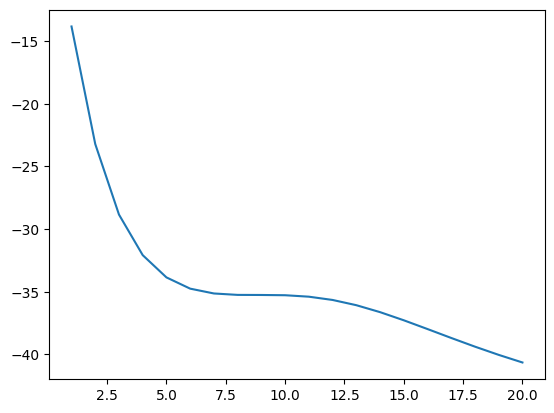

In [127]:
plt.plot(M, energies)

In [122]:
energies

[np.float64(-13.817222051806075),
 np.float64(-23.20762014603304),
 np.float64(-28.842253105178457),
 np.float64(-32.08219432385411),
 np.float64(-33.86005767505616),
 np.float64(-34.75810243606831),
 np.float64(-35.14337725497454),
 np.float64(-35.25658872535305),
 np.float64(-35.263704103902406),
 np.float64(-35.28364013232872),
 np.float64(-35.399798861945435),
 np.float64(-35.660963141239314),
 np.float64(-36.079208784696604),
 np.float64(-36.63383845542468),
 np.float64(-37.28417372283218),
 np.float64(-37.98495394927996),
 np.float64(-38.69694202907627),
 np.float64(-39.39094111394271),
 np.float64(-40.047508740371704),
 np.float64(-40.65499149421424)]